# 19 · Copulas: Modeling Dependence Beyond Correlation

*Module 4 — Statistical Modeling*

Two portfolios can have identical correlation and still carry very different risk of a joint crash. This notebook builds the tool that separates "what each asset looks like on its own" from "how they move together" — and shows exactly what a single correlation number can hide.

## 1. Motivation

Two assets have a correlation of 0.7. Does that mean that when one has a terrible day, the other is very likely to as well? Not necessarily — correlation is a single, linear summary of a much richer relationship, and it can look identical for a pair of assets that quietly drift apart during calm periods and violently crash together, and a pair that shows a similar *average* co-movement but with no special tendency to crash together at all. The 2008 financial crisis put a sharp point on this: a specific, widely-used dependence assumption (the Gaussian copula, applied to mortgage-backed securities) was later, and extensively, criticized for badly understating exactly this kind of joint tail risk — a case study we build the tools to understand directly, rather than take on faith.

## 2. Intuition

A **copula** formalizes a genuinely useful separation of concerns: split the description of a joint distribution into two completely independent pieces — (1) what each variable's distribution looks like *on its own* (its **marginal** distribution — is it fat-tailed? skewed? what's its mean and volatility?), and (2) how the variables relate to *each other*, once you strip away the marginals entirely (the **dependence structure**, described purely in terms of each variable's percentile rank). This separation matters because two completely different marginal distributions can share the exact same dependence structure, and — the point this notebook is really about — two dependence structures that produce the *same overall correlation* can behave utterly differently in the tails, where large portfolio losses actually happen.

## 3. Theory

### 3.1 Sklar's theorem

For any joint distribution $F(x,y)$ with marginals $F_X(x)$ and $F_Y(y)$, there exists a function $C$ — the **copula** — such that

$$
F(x,y) = C\big(F_X(x),\, F_Y(y)\big) .
$$

$C$ is itself a joint CDF, but one defined purely on $[0,1]^2$: it takes each variable's own *percentile rank* ($u=F_X(x)$, $v=F_Y(y)$, each uniformly distributed on $[0,1]$ by construction) and describes how those ranks co-move, with the original marginal distributions — mean, volatility, skewness, fat tails, anything variable-specific — factored completely out.

### 3.2 Three copula families

**Gaussian copula.** $C(u,v) = \Phi_\rho\big(\Phi^{-1}(u), \Phi^{-1}(v)\big)$, where $\Phi_\rho$ is the bivariate standard normal CDF with correlation $\rho$. This is, in effect, "correlation, and nothing more" — it inherits all the tail behavior of the normal distribution, which is famously thin-tailed.

**t-copula.** The analogous construction using a bivariate Student-$t$ distribution instead of normal. Unlike the Gaussian copula, it has genuine, symmetric tail dependence — extreme values in both variables really do become more likely to occur *together* as you move into either tail, with the degrees-of-freedom parameter controlling how strong this effect is.

**Clayton copula.** $C(u,v) = \big(u^{-\theta}+v^{-\theta}-1\big)^{-1/\theta}$, $\theta>0$. This is asymmetric by design: it captures **lower**-tail dependence specifically (assets crashing together) without necessarily implying they also *rally* together with the same intensity — arguably a better match for how real equity markets actually behave (a well-documented empirical asymmetry: correlations tend to spike in crashes far more than in rallies).

### 3.3 Tail dependence, made precise

The **lower tail dependence coefficient** answers a specific, risk-relevant question directly: given that one variable is in its own worst $u$-quantile, how likely is the other to be there too, as $u\to0$?

$$
\lambda_L = \lim_{u\to 0^+} P\big(V \le u \mid U \le u\big) = \lim_{u\to 0^+}\frac{C(u,u)}{u} .
$$

**For Clayton**, this is directly derivable: $C(u,u) = (2u^{-\theta}-1)^{-1/\theta}$, so

$$
\frac{C(u,u)}{u} = \Big[u^\theta\big(2u^{-\theta}-1\big)\Big]^{-1/\theta} = \big(2 - u^\theta\big)^{-1/\theta} \;\xrightarrow[u\to 0]{}\; \boxed{\lambda_L = 2^{-1/\theta}} ,
$$

a genuinely positive number for any finite $\theta$ — tail dependence that persists all the way into the extreme tail. **For the Gaussian copula**, a classical (more involved to derive; we state it here and verify it empirically in Section 4) result is $\lambda_L = 0$ for *any* correlation $\rho < 1$ — no matter how strongly correlated two Gaussian-copula variables are in the "everyday" sense, the probability of a joint extreme event vanishes relative to the probability of either individual extreme, as you look deeper and deeper into the tail. This single fact — a Gaussian copula's tail dependence is exactly zero, not just small — is the mathematical core of the widely-discussed criticism that Gaussian-copula-based models badly understated the risk of many mortgages defaulting together in the run-up to 2008.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(81)

## 4. Implementation

### 4.1 Simulating from Gaussian and Clayton copulas, matched on overall dependence

To compare fairly, we match the two copulas on **Kendall's tau** (a rank-based dependence measure, robust to the exact marginal choice) rather than on the Gaussian-specific correlation coefficient, using the standard relationship $\tau = \theta/(\theta+2)$ for Clayton and $\rho = \sin(\pi\tau/2)$ for the equivalent Gaussian copula.

In [2]:
def simulate_clayton_copula(theta, n, rng):
    """Marshall-Olkin algorithm for the Clayton copula: a Gamma frailty variable shared by both legs."""
    V = rng.gamma(shape=1/theta, scale=1.0, size=n)
    E1, E2 = rng.exponential(1.0, n), rng.exponential(1.0, n)
    U1 = (1 + E1/V) ** (-1/theta)
    U2 = (1 + E2/V) ** (-1/theta)
    return U1, U2

def simulate_gaussian_copula(rho, n, rng):
    Z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n)
    return stats.norm.cdf(Z[:, 0]), stats.norm.cdf(Z[:, 1])

theta = 2.0
tau = theta / (theta + 2)
rho_matched = np.sin(np.pi * tau / 2)             # the rho giving a Gaussian copula the SAME Kendall's tau
print(f"Clayton theta={theta}  ->  Kendall's tau={tau:.3f}  ->  matched Gaussian rho={rho_matched:.3f}")

n = 300_000
U1_c, U2_c = simulate_clayton_copula(theta, n, rng)
U1_g, U2_g = simulate_gaussian_copula(rho_matched, n, rng)

tau_check_c, _ = stats.kendalltau(U1_c[:3000], U2_c[:3000])   # kendalltau is O(n log n) but still slow at 300k; subsample
tau_check_g, _ = stats.kendalltau(U1_g[:3000], U2_g[:3000])
print(f"Empirical Kendall's tau -- Clayton: {tau_check_c:.3f}   Gaussian: {tau_check_g:.3f}  (both should match {tau:.3f})")

Clayton theta=2.0  ->  Kendall's tau=0.500  ->  matched Gaussian rho=0.707


Empirical Kendall's tau -- Clayton: 0.503   Gaussian: 0.507  (both should match 0.500)


### 4.2 Empirical tail dependence: does the theory hold up?

In [3]:
u_grid = [0.20, 0.10, 0.05, 0.02, 0.01]
rows = []
for u in u_grid:
    p_clayton = (U2_c[U1_c < u] < u).mean()
    p_gauss = (U2_g[U1_g < u] < u).mean()
    rows.append({'u': u, 'Clayton empirical': p_clayton, 'Gaussian empirical': p_gauss})
tail_table = pd.DataFrame(rows)
tail_table['Clayton theory (2^-1/theta)'] = 2 ** (-1/theta)
tail_table.round(4)

,u,Clayton empirical,Gaussian empirical,Clayton theory (2^-1/theta)
0,0.20,0.7160,0.5690,0.7071
1,0.10,0.7092,0.4705,0.7071
2,0.05,0.7095,0.4022,0.7071
3,0.02,0.7155,0.3185,0.7071
4,0.01,0.7107,0.2737,0.7071


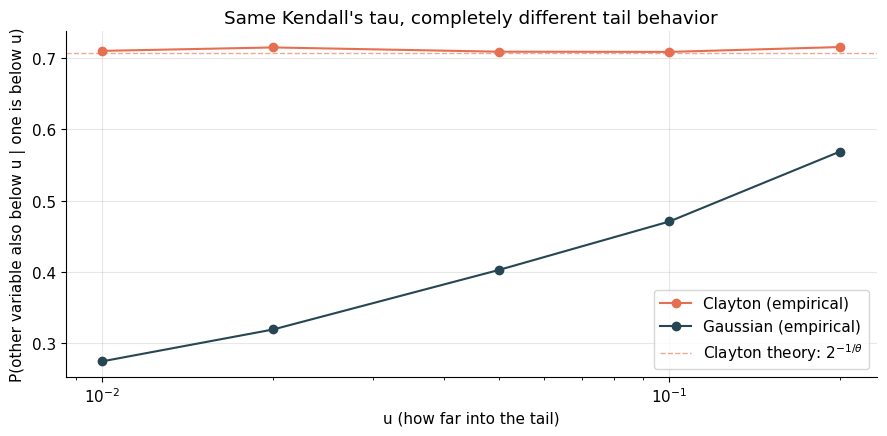

In [4]:
fig, ax = plt.subplots()
ax.plot(tail_table['u'], tail_table['Clayton empirical'], 'o-', color='#e76f51', label='Clayton (empirical)')
ax.plot(tail_table['u'], tail_table['Gaussian empirical'], 'o-', color='#264653', label='Gaussian (empirical)')
ax.axhline(2**(-1/theta), color='#e76f51', linestyle='--', linewidth=1, alpha=0.6, label=r'Clayton theory: $2^{-1/\theta}$')
ax.set_xscale('log')
ax.set_xlabel('u (how far into the tail)')
ax.set_ylabel('P(other variable also below u | one is below u)')
ax.set_title("Same Kendall's tau, completely different tail behavior")
ax.legend()
plt.tight_layout()
plt.show()

As $u$ shrinks, the Clayton copula's conditional probability holds essentially flat at its theoretical limit $2^{-1/\theta}$, while the Gaussian copula's visibly decays toward zero — a direct, numerical confirmation of the $\lambda_L=0$ result stated in Section 3.3, and a striking way to see it: **two dependence structures that look identical by Kendall's tau behave completely differently exactly where portfolio losses are concentrated.**

## 5. Worked example: a two-asset stress test

In [5]:
df_t = 5   # fat-tailed Student-t marginals for both assets -- realistic, and identical across both copula choices
X1_c, X2_c = stats.t.ppf(U1_c, df_t), stats.t.ppf(U2_c, df_t)
X1_g, X2_g = stats.t.ppf(U1_g, df_t), stats.t.ppf(U2_g, df_t)

rows = []
for q_level in [0.10, 0.05, 0.01]:
    q = stats.t.ppf(q_level, df_t)
    p_clayton = ((X1_c < q) & (X2_c < q)).mean()
    p_gauss = ((X1_g < q) & (X2_g < q)).mean()
    p_indep = q_level ** 2
    rows.append({'quantile': q_level, 'Clayton': p_clayton, 'Gaussian (matched tau)': p_gauss,
                 'if independent': p_indep, 'Clayton / Gaussian ratio': p_clayton / p_gauss})
stress_table = pd.DataFrame(rows)
stress_table.round(4)

,quantile,Clayton,Gaussian (matched tau),if independent,Clayton / Gaussian ratio
0,0.10,0.0711,0.0470,0.0100,1.5105
1,0.05,0.0357,0.0199,0.0025,1.7920
2,0.01,0.0074,0.0027,0.0001,2.6927


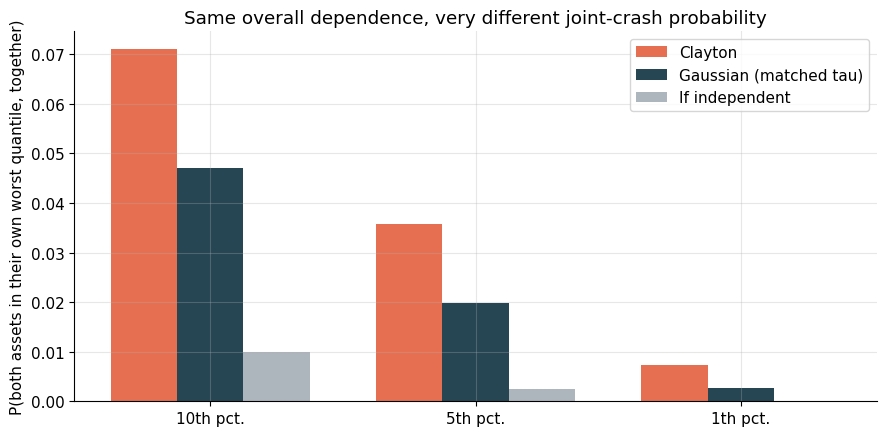

In [6]:
fig, ax = plt.subplots()
width = 0.25
x = np.arange(len(stress_table))
ax.bar(x - width, stress_table['Clayton'], width, label='Clayton', color='#e76f51')
ax.bar(x, stress_table['Gaussian (matched tau)'], width, label='Gaussian (matched tau)', color='#264653')
ax.bar(x + width, stress_table['if independent'], width, label='If independent', color='#adb5bd')
ax.set_xticks(x)
ax.set_xticklabels([f"{int(q*100)}th pct." for q in stress_table['quantile']])
ax.set_ylabel('P(both assets in their own worst quantile, together)')
ax.set_title('Same overall dependence, very different joint-crash probability')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

Look at the `Clayton / Gaussian ratio` column: it does not just stay elevated as we move deeper into the tail — it **grows**. At the 10th percentile the two assumptions might disagree by 50%; at the 1st percentile, the disagreement is far larger, exactly because the Gaussian copula's tail dependence is genuinely collapsing toward zero while Clayton's is not. A risk manager pricing an instrument (or a whole securitization structure) whose payoff depends specifically on the *joint* extreme outcome — both assets crashing together — using a Gaussian-copula assumption would be quoting a probability of that joint disaster that gets progressively more wrong precisely in the tail region the instrument's risk actually depends on. This is not a subtle, arguable modeling nuance; it is a structural, provable property of the Gaussian copula, and it is exactly the mechanism behind the widely-discussed criticism of Gaussian-copula-based models in the years following the 2008 financial crisis.

## 6. Limitations and pitfalls

- **The choice of copula family is itself a modeling assumption**, no more automatically "correct" than choosing a covariance matrix was in Module 2 — Clayton captures lower-tail dependence specifically, but real dependence structures may be more complex still (asymmetric in ways Clayton doesn't capture, time-varying, or better matched by other Archimedean or non-Archimedean families entirely).
- **Estimating a copula's tail parameter reliably requires genuine tail data** — by definition, the rarest, hardest-to-observe part of any historical sample — making this exactly the kind of estimation problem where overconfidence is easiest and most dangerous.
- **Extending beyond two assets is not trivial.** Multivariate Archimedean copulas (like the bivariate Clayton used here) impose restrictive symmetry assumptions across all pairs simultaneously; more flexible constructions (vine copulas, hierarchical structures) exist but add real complexity.
- **A copula describes a static, single-period dependence snapshot.** It says nothing on its own about how dependence *evolves* through time (correlations rising specifically during a crisis, as opposed to being uniformly elevated) — combining a copula with a dynamic, time-varying model of the marginals or the dependence parameter itself is an active area of financial econometrics, well beyond this notebook's scope.
- **Good tail-dependence modeling is necessary, not sufficient, for good risk management.** It has to be combined with everything else in this course — position sizing, stress testing methodology, honest backtesting — not treated as a single fix.

## 7. Exercises

**1. Upper-tail behavior (warm-up).**
Using the same simulated `U1_c, U2_c` and `U1_g, U2_g`, compute the *upper*-tail analogue of Section 4.2's table: $P(V > 1-u \mid U > 1-u)$ for the same grid of small $u$ values. Does the Clayton copula show the same strong tail dependence on the upside that it showed on the downside? Explain, in your own words, why the answer should *not* be symmetric, given the Clayton copula's definition.

**2. The t-copula, empirically.**
Simulate from a bivariate t-copula (via `scipy.stats.multivariate_t` for the underlying draw, then transform each margin through its own Student-t CDF to get uniforms, exactly as Section 4.1 did for the Gaussian case) with a few different degrees-of-freedom values, matched to the same Kendall's tau as the Clayton example. Compute its empirical lower-tail dependence at the same grid of $u$ values used in Section 4.2. Where does the t-copula sit relative to Gaussian (zero tail dependence) and Clayton (strong tail dependence) — and how does its tail dependence change as the degrees of freedom increase toward a large number (which should push it back toward Gaussian-like behavior)?

**3. Three assets and a real portfolio stress test.**
Extend the Clayton-copula simulation approach to three assets (the Marshall-Olkin construction generalizes directly: one shared frailty variable $V$, three independent exponentials transformed the same way). Assign each asset a different, realistic volatility, combine with the shared Clayton dependence structure, and compute the probability that a simple equal-weighted 3-asset portfolio loses more than, say, 15% in a single period. Compare this probability to what you would get assuming a Gaussian copula matched on pairwise Kendall's tau instead. How much does the choice of copula change your estimate of a genuinely portfolio-level tail risk, as opposed to the pairwise comparisons used throughout the rest of this notebook?